In [1]:
from mpramnist.DNASynBench import SimpleMotifDataset, LinCoopDataset
from mpramnist.DNASynBench import LitModel_DNASyn_CLS, LitModel_DNASyn_REG

from mpramnist.models import HumanLegNet, BHI, GENA_LM
from mpramnist.models import initialize_weights

from mpramnist import transforms as t
import torch
import torch.nn as nn
import torch.utils.data as data

import lightning.pytorch as L

BATCH_SIZE = 256
NUM_WORKERS = 8

In [3]:
# Define set of transforms
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

# Generating task 1 (simple classification)
dataset = SimpleMotifDataset()
dataset.generate(motif='AGCAGGT',
    length=200,
    n_seqs=100000,
    ratio=0.6,
    train_size=0.7,
    random_state=42)

train_dataset = dataset.get_split("train", transform=train_transform)
val_dataset = dataset.get_split("val", transform=val_test_transform)
test_dataset = dataset.get_split("test", transform=val_test_transform)

# Encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = train_dataset.n_classes   # = 1 in case of regression task

100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 18984.71it/s]


In [4]:
dataset.df.head()

,sequence,target,split
0,AATGTACGCCATATGCGACCCTGATGCCATTAGCTATATTATATCA...,0,train
1,TCCTGTAACCGGCGGTTTACCGGTCAGACCTAAAGTTCATGCTTTA...,0,train
2,TTAAATGCACGCCATAAGGATACCGAACGTCACAAAGTTTACTAAA...,1,train
3,ATGAGCGAGGTTAAGCACACCCTTGGTGAAGCCGCCATTCTTAGAA...,0,train
4,TAATTACGCCTTCAGAAGGGAGATTTAGAACCTACGGAGGGGTAAC...,0,train


### LegNet

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]
Loading `train_dataloader` to estimate number of stepping batches.
/home/vastre34/miniconda3/envs/mpramnist/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, u

Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

...

`Trainer.fit` stopped: `max_epochs=10` reached.



----------------------------------------------------------------------------------------------------
| Epoch: 9 | Val AUROC: 0.9952335357666016 
| Val Precision: 0.9971999526023865 | Val Recall: 0.9957099556922913 | Val F1: 0.9964417815208435 
----------------------------------------------------------------------------------------------------



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Testing: |                                                                                        | 0/? [00:00…


----------------------------------------------------------------------------------------------------
| Epoch: 10 | Test AUROC: 0.9950866103172302 
| Test Precision: 0.9974638819694519 | Test Recall: 0.9961519241333008 | Test F1: 0.9967972040176392 
----------------------------------------------------------------------------------------------------



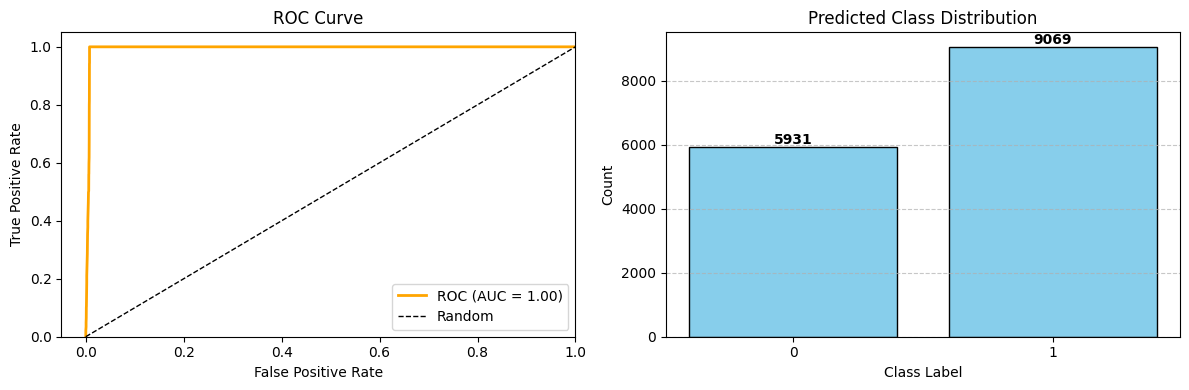

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_f1          │    0.9967972040176392     │
│         test_loss         │   0.019378947094082832    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.019378947094082832, 'test_f1': 0.9967972040176392}]

In [5]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_DNASyn_CLS(
    model=model,
    n_classes=out_channels,
    weight_decay=1e-4,
    lr=1e-2,
    print_each=5
)
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=10,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

### GENA-LM

In [6]:
train_transform = t.Compose([t.ReverseComplement(0.5)])

# Generating task 2 (linear regression)
dataset = LinCoopDataset()
dataset.generate(motif='AGCAGGT',
    length=200,
    n_seqs=100000,
    min_num=0,
    max_num=5,
    train_size=0.7,
    random_state=42)

train_dataset = dataset.get_split("train", transform=train_transform)
val_dataset = dataset.get_split("val")
test_dataset = dataset.get_split("test")

train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
in_channels = len(train_dataset[0][0])
out_channels = 1   # = train_dataset.n_classes in case of classification task

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:29<00:00, 3436.61it/s]


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]
Loading `train_dataloader` to estimate number of stepping batches.
/home/vastre34/miniconda3/envs/mpramnist/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | model         | GENA_LM         | 110 M  | train
1 | loss          | MSELoss         | 0      | train
2 | train_pearson | PearsonCorrCoef | 0      | train
3 | val_pearson   | Pear

Training: |                                                                                       | 0/? [00:00…

/home/vastre34/miniconda3/envs/mpramnist/lib/python3.12/site-packages/lightning/pytorch/core/module.py:1293: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate


Validation: |                                                                                     | 0/? [00:00…

...

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…


-------------------------------------------------------------------------------
| Epoch: 9 | Val Loss: 0.00090 | Val Pearson: 0.99607 | Train Pearson: 0.99726 
-------------------------------------------------------------------------------



`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Testing: |                                                                                        | 0/? [00:00…

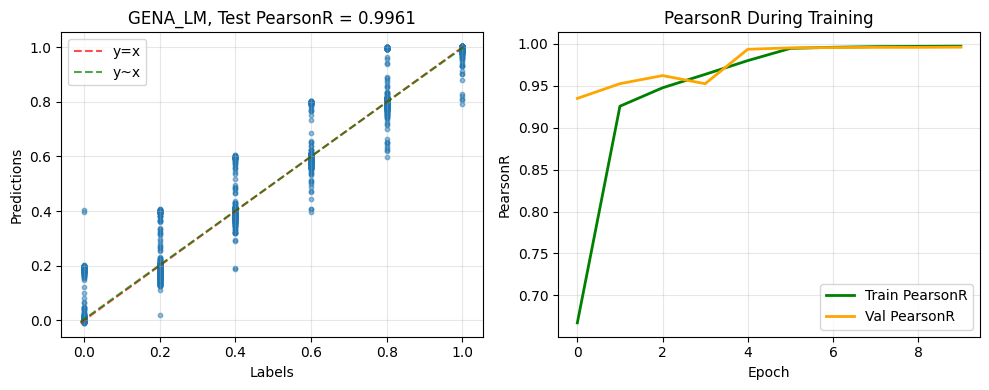

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0009130926919169724   │
│       test_pearson        │    0.9960752129554749     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0009130926919169724, 'test_pearson': 0.9960752129554749}]

In [7]:
model = GENA_LM(
    model_name="AIRI-Institute/gena-lm-bert-base-t2t",
    task="regression",
    seqsize=200,
    num_labels=out_channels
)
model.apply(initialize_weights)

seq_model = LitModel_DNASyn_REG(
    model=model,
    weight_decay=1e-4,
    print_each=5
)
seq_model.optimizer = torch.optim.AdamW([{"params": model.encoder.parameters(), "lr": 1e-4},
                               {"params": model.classifier.parameters(), "lr": 1e-3}])

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=10,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)